<a href="https://colab.research.google.com/github/jotaeleb/tif-ciencias-de-datos/blob/main/notebooks/proyecto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Integrador
El dataset fue diseñado por el Canadian Institute for Cybersecurity (CIC) para el desarrollo y evaluación de sistemas de detección de intrusiones. Contiene más de 2,8 millones de instancias capturadas durante 5 días, incluyendo tráfico normal y ataques como Brute Force, Heartbleed, Botnet, DoS, DDoS, Web Attack e Infiltración. Tiene 79 columnas con 78 features numéricas y una columna categórica de etiqueta (Label).

Fuente: https://www.unb.ca/cic/datasets/ids-2017.html

https://www.kaggle.com/datasets/chethuhn/network-intrusion-dataset

# 1. Definición del Problema

**Problema**: Clasificar tráfico de red como benigno vs malicioso y eventualmente por tipo de ataque.

**Tipo de problema**: Clasificación supervisada

**Objetivo**:
* Detectar intrusiones con alta precisión y recall
* Minimizar falsos negativos (ataques no detectados)

## ⚠️ Problemas del dataset

* **Tamaño del archivo**: 2,8M de filas puede ser lento en máquinas locales. Nosotros vamos a trabajar con arquivos .parquet ya que optimiza el almacenamiento mediante una estructura columnar que maximiza la compresión y acelera las consultas al leer solo los datos necesarios.

* **Valores infinitos**: las features Flow Bytes/s y Flow Packets/s contienen np.inf. Convertirlos a NaN y decidir si eliminamos esas filas o imputarles un valor promedio.

* **Desbalance severo de clases**: BENIGN representa ~80% de los registros. Requiere estrategia de balanceo.

# 2. Configuración, carga y observación Inicial del dataset

In [9]:
# Librerias
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# Configuración de carpetas
DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/Dataset"

# Buscar todos los archivos .parquet en esa carpeta automáticamente
parquet_files = glob.glob(os.path.join(DATA_DIR, "*.parquet"))

# Unir todos los archivos en uno solo
dfs_list = []
for file in parquet_files:
    df_temp = pd.read_parquet(file)
    dfs_list.append(df_temp)

df = pd.concat(dfs_list, ignore_index=True)

# Limpieza básica de nombres de columnas
df.columns = df.columns.str.strip()

print(f"Dataset cargado con {df.shape[0]} filas y con {df.shape[1]} columnas.")

Dataset cargado con 2830743 filas y con 79 columnas.


In [10]:
# Ver las primeras 5 filas
pd.set_option('display.max_rows', None)
df.head().T.round(2)

,0,1,2,3,4
Destination Port,54865,55054,55055,46236,54863
Flow Duration,3,109,52,34,3
Total Fwd Packets,2,1,1,1,2
Total Backward Packets,0,1,1,1,0
Total Length of Fwd Packets,12,6,6,6,12
Total Length of Bwd Packets,0,6,6,6,0
Fwd Packet Length Max,6,6,6,6,6
Fwd Packet Length Min,6,6,6,6,6
Fwd Packet Length Mean,6.00,6.00,6.00,6.00,6.00
Fwd Packet Length Std,0.00,0.00,0.00,0.00,0.00


In [7]:
# Información general: tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Backward Packets       int64  
 4   Total Length of Fwd Packets  int64  
 5   Total Length of Bwd Packets  int64  
 6   Fwd Packet Length Max        int64  
 7   Fwd Packet Length Min        int64  
 8   Fwd Packet Length Mean       float64
 9   Fwd Packet Length Std        float64
 10  Bwd Packet Length Max        int64  
 11  Bwd Packet Length Min        int64  
 12  Bwd Packet Length Mean       float64
 13  Bwd Packet Length Std        float64
 14  Flow Bytes/s                 float64
 15  Flow Packets/s               float64
 16  Flow IAT Mean                float64
 17  Flow IAT Std                 float64
 18  Flow IAT Max                 int64  
 19  

In [16]:
# Separar tipos
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns

print("Numéricas:", len(num_cols))
print("Categóricas:", cat_cols)

Numéricas: 78
Categóricas: Index(['Label'], dtype='object')


### Preguntas:

**¿Cuántas filas y columnas hay?** El dataset contiene 2.830.743 filas y 79 columnas.

**¿Qué tipos de datos aparecen?** Predominan variables numéricas (78) y una variable categórica (Label).

# 3. Identificación de la variable objetivo

In [22]:
counts = df['Label'].value_counts()
pd.DataFrame({'Conteo': counts.map('{:,}'.format),
              '%': (counts/len(df)*100).map('{:.1f}'.format)})

,Conteo,%
Label,,
BENIGN,"2,273,097",80.3
DoS Hulk,"231,073",8.2
PortScan,"158,930",5.6
DDoS,"128,027",4.5
DoS GoldenEye,"10,293",0.4
FTP-Patator,"7,938",0.3
SSH-Patator,"5,897",0.2
DoS slowloris,"5,796",0.2
DoS Slowhttptest,"5,499",0.2


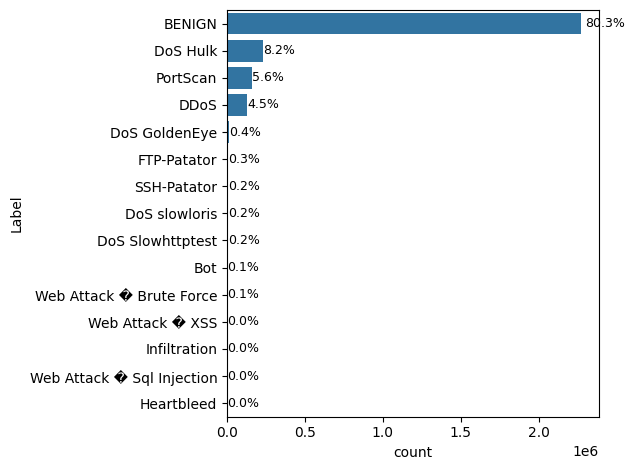

In [14]:
# Calcular conteos y porcentajes
counts = df['Label'].value_counts()
percentages = df['Label'].value_counts(normalize=True) * 100

# Gráfico horizontal ordenado (mayor a menor)
ax = sns.countplot(y='Label', data=df, order=counts.index)

# Añadir porcentaje al final de cada barra
for i, (label, count, pct) in enumerate(zip(counts.index, counts.values, percentages.values)):
    ax.text(count + (count * 0.01), i, f'{pct:.1f}%',
            va='center', ha='left', fontsize=9)

plt.tight_layout()
plt.show()

### Preguntas:

**¿Cuál es la variable objetivo?**
La variable objetivo es Label, que indica si el tráfico es benigno o un tipo de ataque.

**¿Hay múltiples clases o solo binario?**
Hay múltiples clases (multiclase), incluyendo distintos tipos de ataques.

**¿Qué variables parecen derivadas?**
Muchas variables representan métricas de red, por ejemplo:
Flow Duration, Total Fwd Packets, Flow Bytes/s y Flow Packets/s
Estas son features ingenierizadas a partir del tráfico.

**¿Está balanceado el dataset?**
No, el dataset está desbalanceado, ya que la clase BENIGN representa el 80% de los datos.

**¿Qué ataques dominan?**
Los 3 ataques más frecuentes son: DoS Hulk, PortScan y DDoS. Mientras que otros como Heartbleed, Web Attack-Sql Injection	o Infiltration son extremadamente raros.


#4.  Estadísticas descriptivas

In [17]:
# Desactivar notación científica y mostrar números normales
pd.set_option('display.float_format', '{:.2f}'.format)

# Mostrar tabla
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Destination Port,2830743.00,8071.48,18283.63,0.00,53.00,80.00,443.00,65535.00
Flow Duration,2830743.00,14785663.93,33653744.09,-13.00,155.00,31316.00,3204828.50,119999998.00
Total Fwd Packets,2830743.00,9.36,749.67,1.00,2.00,2.00,5.00,219759.00
Total Backward Packets,2830743.00,10.39,997.39,0.00,1.00,2.00,4.00,291922.00
Total Length of Fwd Packets,2830743.00,549.30,9993.59,0.00,12.00,62.00,187.00,12900000.00
Total Length of Bwd Packets,2830743.00,16162.64,2263088.05,0.00,0.00,123.00,482.00,655453030.00
Fwd Packet Length Max,2830743.00,207.60,717.18,0.00,6.00,37.00,81.00,24820.00
Fwd Packet Length Min,2830743.00,18.71,60.34,0.00,0.00,2.00,36.00,2325.00
Fwd Packet Length Mean,2830743.00,58.20,186.09,0.00,6.00,34.00,50.00,5940.86
Fwd Packet Length Std,2830743.00,68.91,281.19,0.00,0.00,0.00,26.16,7125.60


In [18]:
# Ver valores infinitos por columna
inf_por_columna = np.isinf(df[num_cols]).sum()
print(inf_por_columna[inf_por_columna > 0])

Flow Bytes/s      1509
Flow Packets/s    2867
dtype: int64


In [19]:
#Reemplazar loa valores infinitos
df.replace([np.inf, -np.inf], np.nan, inplace=True)

In [20]:
# Valores faltantes (solo los que son > 0)
df.isnull().sum()[df.isnull().sum() > 0]

,0
Flow Bytes/s,2867
Flow Packets/s,2867


### Preguntas:

**¿Cómo se distribuyen las variables?**
Las variables presentan alta dispersión, distribuciones sesgadas (no normales) y valores extremos en varias columnas.

**¿Hay valores raros?**
Sí, existen valores infinitos (np.inf) en variables como: Flow Bytes/s y Flow Packets/s.
Estos deben tratarse antes de modelar.


**¿Hay valores faltantes?** Sí, existen valores faltantes de la variable Flow Bytes/s y Flow Packets/s.



In [ ]:
# Outliers
# Boxplot horizontal con todas las variables
plt.figure(figsize=(12, n_vars * 0.5))
sns.boxplot(data=df[num_cols], orient='h')
plt.tight_layout()
plt.show()